In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
# Display the number of rows and columns
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display data types
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (101766, 50)

Column Names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Data Types:
encounter_id                int64
patient_nbr                 int64
race                          str
gender                  

In [5]:
# Check missing values
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

max_glu_serum    96420
A1Cresult        84748
dtype: int64


In [6]:
(df == "?").sum().sort_values(ascending=False)

weight                      98569
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
admission_type_id               0
patient_nbr                     0
encounter_id                    0
time_in_hospital                0
admission_source_id             0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
discharge_disposition_id        0
gender                          0
age                             0
number_inpatient                0
number_emergency                0
number_outpatient               0
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [7]:
df["readmitted"].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [8]:
import numpy as np

# Replace ? with NaN
df.replace("?", np.nan, inplace=True)

# Check missing values again
df.isnull().sum().sort_values(ascending=False).head(15)

weight                 98569
max_glu_serum          96420
A1Cresult              84748
medical_specialty      49949
payer_code             40256
race                    2273
diag_3                  1423
diag_2                   358
diag_1                    21
patient_nbr                0
time_in_hospital           0
admission_source_id        0
num_lab_procedures         0
encounter_id               0
admission_type_id          0
dtype: int64

In [9]:
# Percentage of missing values

missing_percent = df.isnull().mean()*100

missing_percent.sort_values(ascending=False).head(15)

weight                 96.858479
max_glu_serum          94.746772
A1Cresult              83.277322
medical_specialty      49.082208
payer_code             39.557416
race                    2.233555
diag_3                  1.398306
diag_2                  0.351787
diag_1                  0.020636
patient_nbr             0.000000
time_in_hospital        0.000000
admission_source_id     0.000000
num_lab_procedures      0.000000
encounter_id            0.000000
admission_type_id       0.000000
dtype: float64

In [10]:
# Drop columns with excessive missing values

df.drop(columns=['weight', 'payer_code', 'medical_specialty'], inplace=True)

print(df.shape)

(101766, 47)


In [11]:
df.isnull().sum().sort_values(ascending=False).head(10)

max_glu_serum          96420
A1Cresult              84748
race                    2273
diag_3                  1423
diag_2                   358
diag_1                    21
encounter_id               0
admission_source_id        0
time_in_hospital           0
num_lab_procedures         0
dtype: int64

In [12]:
df.drop(columns=['max_glu_serum', 'A1Cresult'], inplace=True)

print(df.shape)

(101766, 45)


In [13]:
df.isnull().sum().sort_values(ascending=False).head(10)

race                        2273
diag_3                      1423
diag_2                       358
diag_1                        21
encounter_id                   0
admission_type_id              0
discharge_disposition_id       0
admission_source_id            0
time_in_hospital               0
num_lab_procedures             0
dtype: int64

In [14]:
# Fill missing categorical values with the most frequent value (mode)

for col in ['race', 'diag_1', 'diag_2', 'diag_3']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Verify that no missing values remain
df.isnull().sum().sort_values(ascending=False).head(10)

C:\Users\HP\AppData\Local\Temp\ipykernel_820\948618841.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].mode()[0], inplace=True)


race                        2273
diag_3                      1423
diag_2                       358
diag_1                        21
encounter_id                   0
admission_type_id              0
discharge_disposition_id       0
admission_source_id            0
time_in_hospital               0
num_lab_procedures             0
dtype: int64

In [15]:
fill_values = {
    'race': df['race'].mode()[0],
    'diag_1': df['diag_1'].mode()[0],
    'diag_2': df['diag_2'].mode()[0],
    'diag_3': df['diag_3'].mode()[0]
}

df.fillna(fill_values, inplace=True)

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),1,3,7,3,51,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),1,4,5,5,33,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),1,1,7,1,53,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),2,3,7,10,45,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [16]:
df.isnull().sum().sort_values(ascending=False).head(10)

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
dtype: int64

In [17]:
# Convert readmitted to binary
df['readmitted'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# Check the distribution
print(df['readmitted'].value_counts())

readmitted
0    90409
1    11357
Name: count, dtype: int64


In [18]:
df.drop(columns=['encounter_id', 'patient_nbr'], inplace=True)

print(df.shape)

(101766, 43)


In [19]:
def categorize_diagnosis(diag):
    diag = str(diag)

    # Handle V-codes
    if diag.startswith("V"):
        return "Supplementary"

    # Handle E-codes
    if diag.startswith("E"):
        return "External Injury"

    try:
        diag = float(diag)

        if 390 <= diag <= 459 or diag == 785:
            return "Circulatory"

        elif 460 <= diag <= 519 or diag == 786:
            return "Respiratory"

        elif 520 <= diag <= 579 or diag == 787:
            return "Digestive"

        elif 250 <= diag < 251:
            return "Diabetes"

        elif 800 <= diag <= 999:
            return "Injury"

        elif 710 <= diag <= 739:
            return "Musculoskeletal"

        elif 580 <= diag <= 629 or diag == 788:
            return "Genitourinary"

        elif 140 <= diag <= 239:
            return "Neoplasms"

        else:
            return "Other"

    except:
        return "Other"

In [20]:
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].apply(categorize_diagnosis)

In [21]:
df[['diag_1', 'diag_2', 'diag_3']].head(10)

,diag_1,diag_2,diag_3
0,Diabetes,Other,Diabetes
1,Other,Diabetes,Other
2,Other,Diabetes,Supplementary
3,Other,Diabetes,Circulatory
4,Neoplasms,Neoplasms,Diabetes
5,Circulatory,Circulatory,Diabetes
6,Circulatory,Circulatory,Supplementary
7,Circulatory,Respiratory,Diabetes
8,Circulatory,Circulatory,Other
9,Circulatory,Neoplasms,Respiratory


In [22]:
for col in ['diag_1', 'diag_2', 'diag_3']:
    print(f"\n{col}")
    print(df[col].value_counts())


diag_1
diag_1
Circulatory        30458
Other              16527
Respiratory        14423
Digestive           9475
Diabetes            8757
Injury              6974
Genitourinary       5117
Musculoskeletal     4957
Neoplasms           3433
Supplementary       1644
External Injury        1
Name: count, dtype: int64

diag_2
diag_2
Circulatory        31881
Other              24375
Diabetes           12794
Respiratory        10895
Genitourinary       8376
Digestive           4170
Neoplasms           2547
Injury              2428
Supplementary       1805
Musculoskeletal     1764
External Injury      731
Name: count, dtype: int64

diag_3
diag_3
Circulatory        30306
Other              24137
Diabetes           18580
Respiratory         7358
Genitourinary       6680
Digestive           3930
Supplementary       3814
Injury              1946
Musculoskeletal     1915
Neoplasms           1856
External Injury     1244
Name: count, dtype: int64


In [23]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object', 'string']).columns

# Encode all categorical variables
encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col].astype(str))

print("Encoding completed successfully!")

Encoding completed successfully!


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 43 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   race                      101766 non-null  int64
 1   gender                    101766 non-null  int64
 2   age                       101766 non-null  int64
 3   admission_type_id         101766 non-null  int64
 4   discharge_disposition_id  101766 non-null  int64
 5   admission_source_id       101766 non-null  int64
 6   time_in_hospital          101766 non-null  int64
 7   num_lab_procedures        101766 non-null  int64
 8   num_procedures            101766 non-null  int64
 9   num_medications           101766 non-null  int64
 10  number_outpatient         101766 non-null  int64
 11  number_emergency          101766 non-null  int64
 12  number_inpatient          101766 non-null  int64
 13  diag_1                    101766 non-null  int64
 14  diag_2                    10176

In [25]:
from sklearn.model_selection import train_test_split

X = df.drop("readmitted", axis=1)
y = df["readmitted"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (81412, 42)
Testing set : (20354, 42)


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
7,num_lab_procedures,0.118859
9,num_medications,0.100740
6,time_in_hospital,0.068739
15,diag_3,0.060250
14,diag_2,0.058284
2,age,0.058118
13,diag_1,0.057579
12,number_inpatient,0.049869
8,num_procedures,0.048497
4,discharge_disposition_id,0.045491


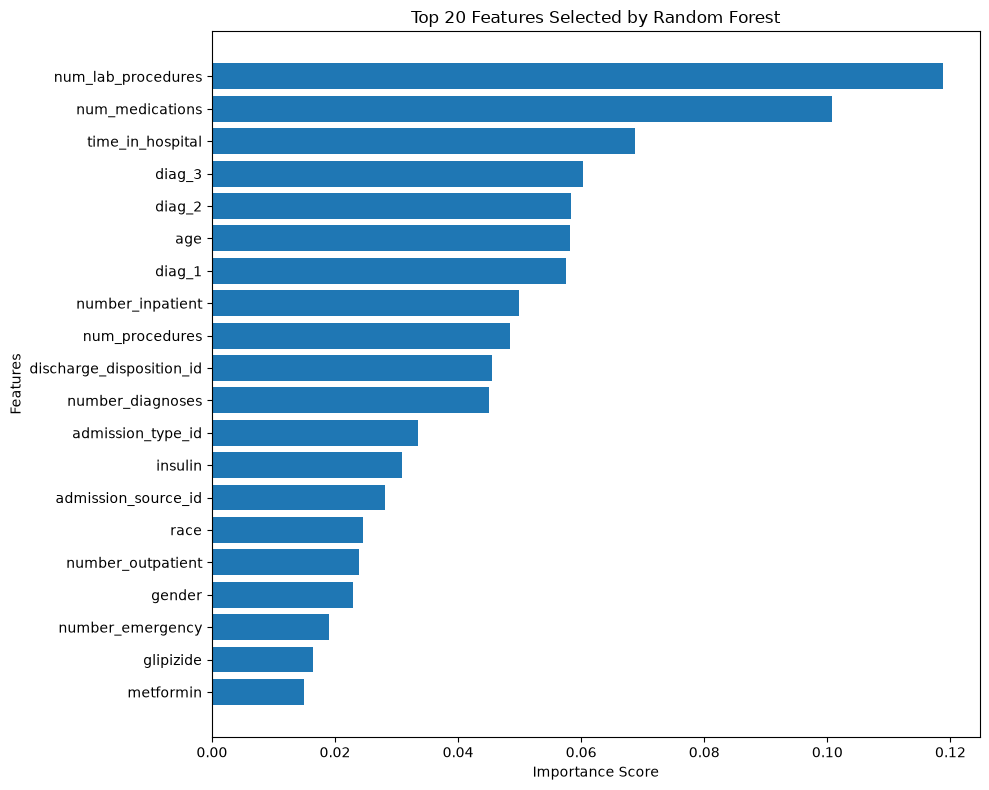

In [27]:
import matplotlib.pyplot as plt

top20 = feature_importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(top20["Feature"], top20["Importance"])

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 20 Features Selected by Random Forest")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [28]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

# Extract feature importance
dt_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dt.feature_importances_
})

dt_importance = dt_importance.sort_values(
    by="Importance",
    ascending=False
)

dt_importance.head(20)

,Feature,Importance
7,num_lab_procedures,0.139924
9,num_medications,0.113470
6,time_in_hospital,0.070965
14,diag_2,0.060604
15,diag_3,0.057315
2,age,0.057101
13,diag_1,0.049192
8,num_procedures,0.049042
34,insulin,0.039473
16,number_diagnoses,0.038777


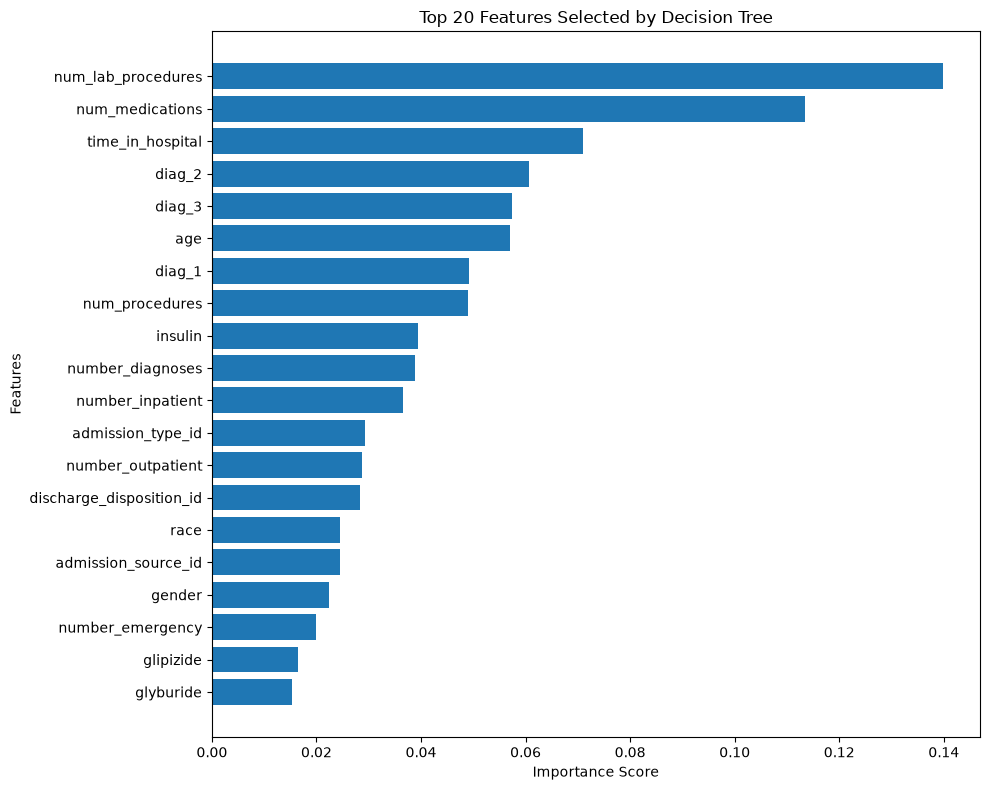

In [29]:
top20_dt = dt_importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(top20_dt["Feature"], top20_dt["Importance"])

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 20 Features Selected by Decision Tree")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [30]:
comparison = pd.merge(
    feature_importance.head(20),
    dt_importance.head(20),
    on="Feature",
    how="outer",
    suffixes=("_RF", "_DT")
)

comparison

,Feature,Importance_RF,Importance_DT
0,admission_source_id,0.028149,0.024451
1,admission_type_id,0.033500,0.029305
2,age,0.058118,0.057101
3,diag_1,0.057579,0.049192
4,diag_2,0.058284,0.060604
5,diag_3,0.060250,0.057315
6,discharge_disposition_id,0.045491,0.028256
7,gender,0.022910,0.022377
8,glipizide,0.016419,0.016509
9,glyburide,NaN,0.015393


In [31]:
selected_features = feature_importance.head(20)["Feature"].tolist()

print(selected_features)

['num_lab_procedures', 'num_medications', 'time_in_hospital', 'diag_3', 'diag_2', 'age', 'diag_1', 'number_inpatient', 'num_procedures', 'discharge_disposition_id', 'number_diagnoses', 'admission_type_id', 'insulin', 'admission_source_id', 'race', 'number_outpatient', 'gender', 'number_emergency', 'glipizide', 'metformin']


In [32]:
X_selected = X[selected_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(81412, 20)
(20354, 20)


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [34]:
results = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
])

In [35]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities (for ROC-AUC)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = np.nan

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    global results

    results.loc[len(results)] = [
        model_name,
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(classification_report(y_test, y_pred, zero_division=0))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

    plt.title(model_name)
    plt.show()

Logistic Regression
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.48      0.01      0.03      2271

    accuracy                           0.89     20354
   macro avg       0.69      0.51      0.48     20354
weighted avg       0.84      0.89      0.84     20354



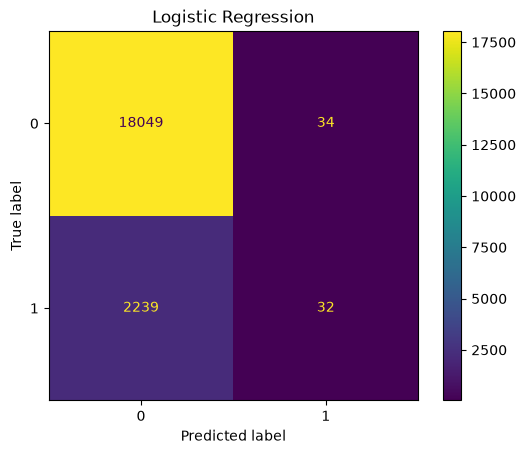

In [36]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

evaluate_model(
    lr,
    X_train,
    X_test,
    y_train,
    y_test,
    "Logistic Regression"
)

Logistic Regression (Balanced)
              precision    recall  f1-score   support

           0       0.92      0.69      0.79     18083
           1       0.17      0.51      0.26      2271

    accuracy                           0.67     20354
   macro avg       0.55      0.60      0.52     20354
weighted avg       0.84      0.67      0.73     20354



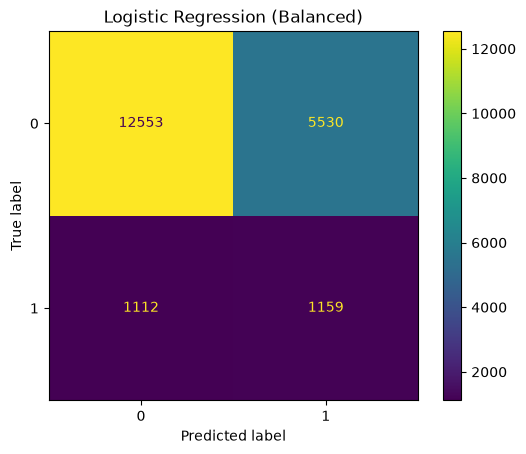

In [37]:
from sklearn.linear_model import LogisticRegression

lr_balanced = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

evaluate_model(
    lr_balanced,
    X_train,
    X_test,
    y_train,
    y_test,
    "Logistic Regression (Balanced)"
)

Decision Tree
              precision    recall  f1-score   support

           0       0.89      0.89      0.89     18083
           1       0.15      0.15      0.15      2271

    accuracy                           0.81     20354
   macro avg       0.52      0.52      0.52     20354
weighted avg       0.81      0.81      0.81     20354



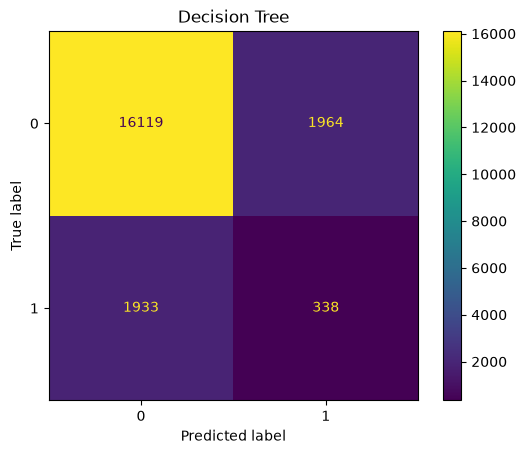

In [38]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

evaluate_model(
    dt,
    X_train,
    X_test,
    y_train,
    y_test,
    "Decision Tree"
)

Random Forest
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     18083
           1       0.37      0.06      0.10      2271

    accuracy                           0.88     20354
   macro avg       0.63      0.52      0.52     20354
weighted avg       0.84      0.88      0.84     20354



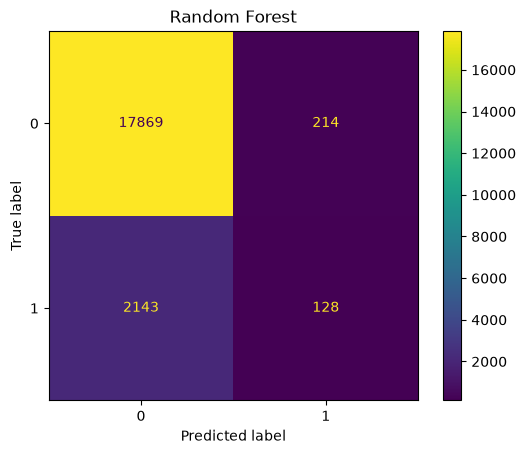

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

evaluate_model(
    rf_model,
    X_train,
    X_test,
    y_train,
    y_test,
    "Random Forest"
)

In [40]:
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.888327,0.484848,0.014091,0.027386,0.642962
1,Logistic Regression (Balanced),0.673676,0.173270,0.510348,0.258705,0.644392
2,Decision Tree,0.808539,0.146829,0.148833,0.147824,0.520111
3,Random Forest,0.884200,0.374269,0.056363,0.097972,0.657125


Linear SVM
Accuracy : 0.6752
Precision: 0.1733
Recall   : 0.5068
F1-score : 0.2583
ROC-AUC  : 0.6435

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.70      0.79     18083
           1       0.17      0.51      0.26      2271

    accuracy                           0.68     20354
   macro avg       0.55      0.60      0.53     20354
weighted avg       0.84      0.68      0.73     20354



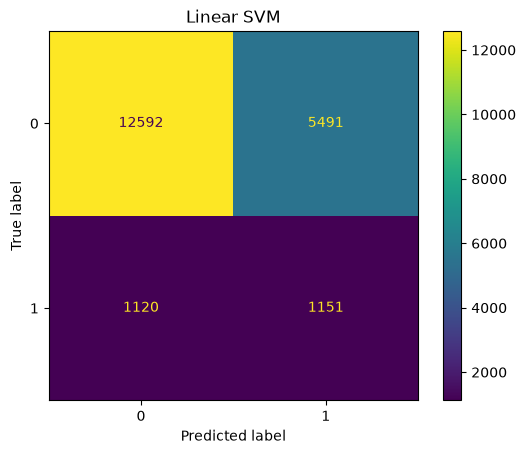

In [42]:
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Train Linear SVM
svm = LinearSVC(
    class_weight='balanced',
    random_state=42,
    dual=False,
    max_iter=3000
)

svm.fit(X_train, y_train)

# Predictions
y_pred = svm.predict(X_test)

# Decision scores for ROC-AUC
y_score = svm.decision_function(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_score)

# Save result
results.loc[len(results)] = [
    "Linear SVM",
    accuracy,
    precision,
    recall,
    f1,
    auc
]

# Print results
print("="*60)
print("Linear SVM")
print("="*60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred, zero_division=0))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Linear SVM")
plt.show()

In [43]:
!pip install xgboost

XGBoost
Accuracy : 0.6765
Precision: 0.1868
Recall   : 0.5663
F1-score : 0.2809
ROC-AUC  : 0.6784

Classification Report

              precision    recall  f1-score   support

           0       0.93      0.69      0.79     18083
           1       0.19      0.57      0.28      2271

    accuracy                           0.68     20354
   macro avg       0.56      0.63      0.54     20354
weighted avg       0.84      0.68      0.73     20354



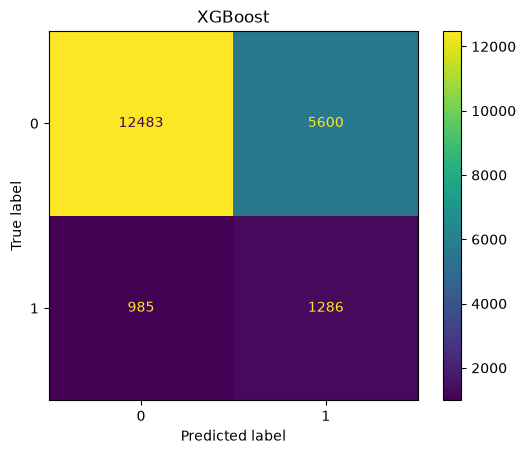

In [44]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Calculate class imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Train XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

# Predictions
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)

# Save result
results.loc[len(results)] = [
    "XGBoost",
    accuracy,
    precision,
    recall,
    f1,
    auc
]

# Display results
print("="*60)
print("XGBoost")
print("="*60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("XGBoost")
plt.show()

In [45]:
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.888327,0.484848,0.014091,0.027386,0.642962
1,Logistic Regression (Balanced),0.673676,0.173270,0.510348,0.258705,0.644392
2,Decision Tree,0.808539,0.146829,0.148833,0.147824,0.520111
3,Random Forest,0.884200,0.374269,0.056363,0.097972,0.657125
4,Linear SVM,0.675199,0.173291,0.506825,0.258274,0.643465
5,XGBoost,0.676476,0.186756,0.566270,0.280878,0.678369


In [46]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

In [47]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

In [48]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

In [49]:
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [4, 6], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits

In [50]:
print("Best Parameters:")
print(grid_search.best_params_)

print()

print("Best F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}

Best F1 Score:
0.26986165588536387


In [51]:
best_xgb = grid_search.best_estimator_

Optimized XGBoost
Accuracy : 0.6397
Precision: 0.1786
Recall   : 0.6196
F1 Score : 0.2773
ROC AUC  : 0.6819

              precision    recall  f1-score   support

           0       0.93      0.64      0.76     18083
           1       0.18      0.62      0.28      2271

    accuracy                           0.64     20354
   macro avg       0.55      0.63      0.52     20354
weighted avg       0.85      0.64      0.71     20354



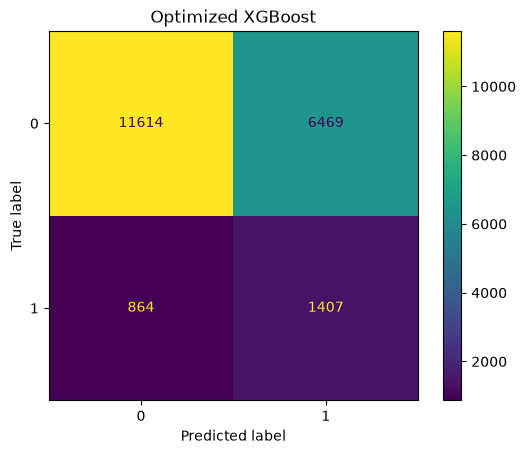

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred,zero_division=0)
recall = recall_score(y_test,y_pred,zero_division=0)
f1 = f1_score(y_test,y_pred,zero_division=0)
auc = roc_auc_score(y_test,y_prob)

print("="*60)
print("Optimized XGBoost")
print("="*60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")

print()

print(classification_report(y_test,y_pred,zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.title("Optimized XGBoost")
plt.show()

In [53]:
results.loc[len(results)] = [
    "Optimized XGBoost",
    accuracy,
    precision,
    recall,
    f1,
    auc
]

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.888327,0.484848,0.014091,0.027386,0.642962
1,Logistic Regression (Balanced),0.673676,0.173270,0.510348,0.258705,0.644392
2,Decision Tree,0.808539,0.146829,0.148833,0.147824,0.520111
3,Random Forest,0.884200,0.374269,0.056363,0.097972,0.657125
4,Linear SVM,0.675199,0.173291,0.506825,0.258274,0.643465
5,XGBoost,0.676476,0.186756,0.566270,0.280878,0.678369
6,Optimized XGBoost,0.639727,0.178644,0.619551,0.277323,0.681876


In [54]:
results.to_csv("model_comparison.csv", index=False)

In [55]:
feature_importance.to_csv("feature_importance.csv", index=False)

In [56]:
import joblib

joblib.dump(best_xgb, "optimized_xgboost_model.pkl")

['optimized_xgboost_model.pkl']

In [57]:
print(selected_features)

['num_lab_procedures', 'num_medications', 'time_in_hospital', 'diag_3', 'diag_2', 'age', 'diag_1', 'number_inpatient', 'num_procedures', 'discharge_disposition_id', 'number_diagnoses', 'admission_type_id', 'insulin', 'admission_source_id', 'race', 'number_outpatient', 'gender', 'number_emergency', 'glipizide', 'metformin']


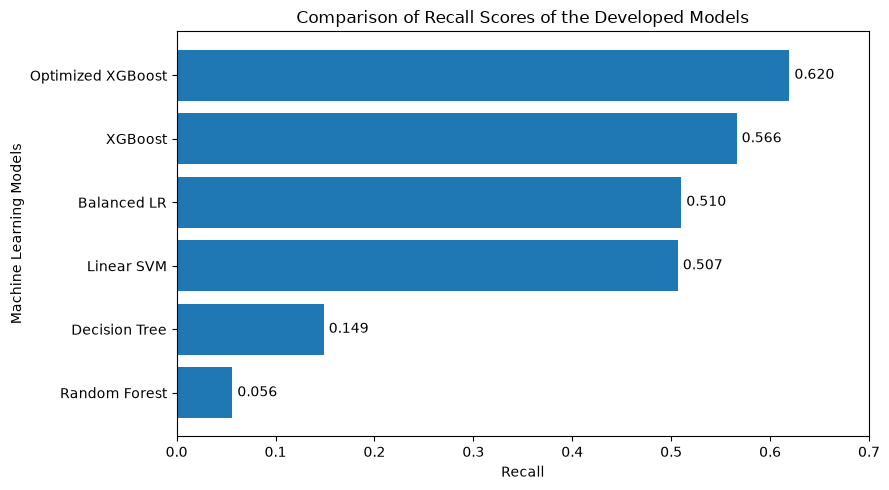

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Model": [
        "Balanced LR",
        "Decision Tree",
        "Random Forest",
        "Linear SVM",
        "XGBoost",
        "Optimized XGBoost"
    ],
    "Recall": [
        0.5103,
        0.1488,
        0.0564,
        0.5068,
        0.5663,
        0.6196
    ]
})

results = results.sort_values("Recall")

plt.figure(figsize=(9,5))
plt.barh(results["Model"], results["Recall"])

plt.xlabel("Recall")
plt.ylabel("Machine Learning Models")
plt.title("Comparison of Recall Scores of the Developed Models")

for i, v in enumerate(results["Recall"]):
    plt.text(v + 0.005, i, f"{v:.3f}", va='center')

plt.xlim(0, 0.70)

plt.tight_layout()

plt.savefig("Recall_Comparison.png", dpi=300, bbox_inches="tight")

plt.show()

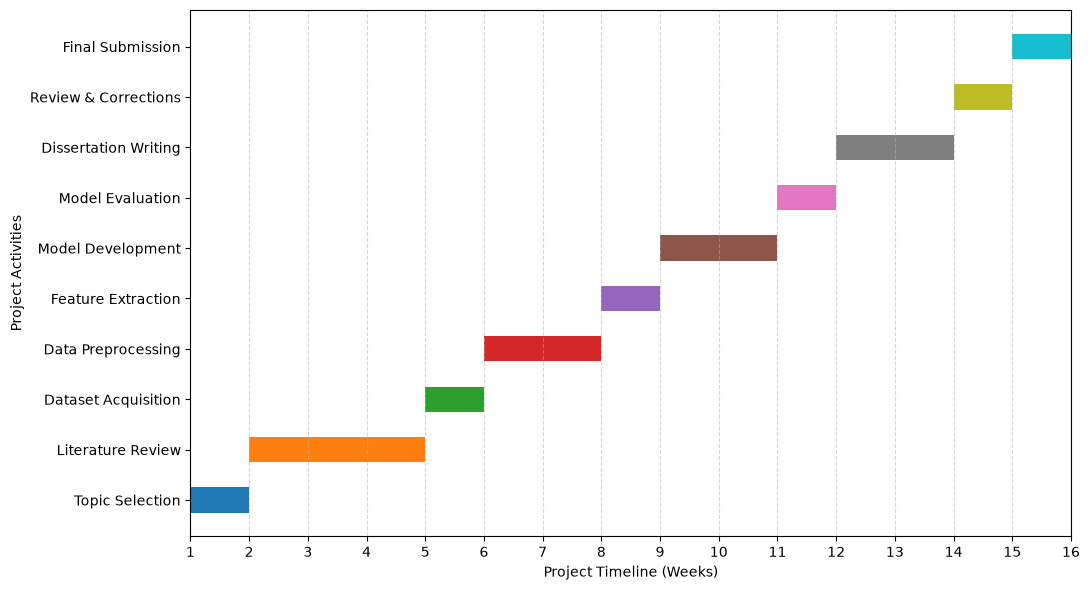

In [60]:
import matplotlib.pyplot as plt

# -----------------------------
# Project Activities
# -----------------------------
tasks = [
    "Topic Selection",
    "Literature Review",
    "Dataset Acquisition",
    "Data Preprocessing",
    "Feature Extraction",
    "Model Development",
    "Model Evaluation",
    "Dissertation Writing",
    "Review & Corrections",
    "Final Submission"
]

# Start week of each task
start = [1, 2, 5, 6, 8, 9, 11, 12, 14, 15]

# Duration (weeks)
duration = [1, 3, 1, 2, 1, 2, 1, 2, 1, 1]

# -----------------------------
# Plot Gantt Chart
# -----------------------------
plt.figure(figsize=(11,6))

for i, task in enumerate(tasks):
    plt.barh(
        y=task,
        width=duration[i],
        left=start[i],
        height=0.5
    )

plt.xlabel("Project Timeline (Weeks)")
plt.ylabel("Project Activities")


plt.xticks(range(1,17))
plt.xlim(1,16)

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()

# Save image
plt.savefig("Gantt_Chart.png", dpi=300)

plt.show()